# EDA

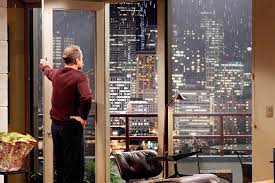

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Phase 1: Daten laden & Datenverständnis

**Kontext:** Unsere Klientin ist **Bonnie Brown**.

> ⚠️ **Korrigiert (2026-07-31):** Diese Einleitung beschrieb Bonnie ursprünglich fälschlich als Käuferin mit Budget ≤ 500.000 $ – das war nirgends belegt (weder im Assignment noch sonst). Laut `01_assignment.md` (Zeile 46) ist Bonnie tatsächlich **Verkäuferin**. Siehe Abschnitt 3.4 für die volle Herleitung des Fehlers und die korrigierte Analyse.

Bonnie ist **Verkäuferin**: Sie besitzt bereits ein Haus in einer **Mittelschicht-Nachbarschaft**, will bald umziehen und möchte beim Verkauf einen möglichst hohen Profit erzielen. Ihre Eckdaten:

- Rolle: **Seller** – sie verkauft ihr eigenes Haus, sie kauft nicht.
- Ihr Haus liegt in einer **Mittelschicht-Nachbarschaft** (definiert über Zipcode-Median-Preis-Terzile, siehe Abschnitt 3.4).
- Sie will **bald verkaufen** (Timing-Frage, Hypothese 3, nicht Teil dieses Notebooks) und dabei den **Profit maximieren** – u.a. durch die Frage, ob sich eine Renovierung vor dem Verkauf lohnt (Hypothese 2, ab Abschnitt 3.4).

Bevor wir filtern oder Hypothesen testen können, müssen wir zuerst die **Rohdaten laden und verstehen**. Diese Phase deckt laut `02_workflow.md` ab:

1. Daten aus der Datenbank laden (SQL-Join über Pandas)
2. Spalte `date` in ein echtes Datetime-Format konvertieren
3. Fehlende Werte (Nulls) prüfen
4. Duplikate prüfen

Wir bereinigen die Daten in diesem Schritt noch **nicht** (kein Imputieren, kein Entfernen) – wir verschaffen uns nur einen Überblick, wie in `02_workflow.md` unter "Understanding the Data" beschrieben.

### 1.1 Daten aus der Datenbank laden

Im `eda`-Schema gibt es zwei Tabellen:

- **`king_county_house_details`**: eine Zeile pro Haus (`id`), mit allen strukturellen Merkmalen (Zimmer, Fläche, Baujahr, Lage, ...)
- **`king_county_house_sales`**: eine Zeile pro Verkauf (`date`, `price`), verknüpft über `house_id` mit `king_county_house_details.id`

Wir joinen beide Tabellen über `sales.house_id = details.id`. Ein Haus kann dabei **mehrfach** auftauchen, wenn es innerhalb des Beobachtungszeitraums mehrmals verkauft wurde – das ist kein Fehler, sondern ein normales Merkmal dieses Datensatzes (dazu mehr im Duplikate-Check weiter unten).

Damit wir nicht bei jedem Notebook-Lauf erneut die Datenbank abfragen müssen, laden wir die Daten einmal per SQL, speichern sie lokal als CSV in `data/` (nicht in git, siehe `.gitignore`) und lesen bei künftigen Läufen direkt aus der CSV.

In [2]:
import os
from pathlib import Path

from dotenv import load_dotenv
from sqlalchemy import create_engine

# Zugangsdaten aus der .env laden (niemals Zugangsdaten hart im Code hinterlegen)
load_dotenv()
DB_STRING = os.getenv("DB_STRING")

if DB_STRING is None:
    raise ValueError("DB_STRING ist nicht in der .env gesetzt. Bitte .env.example kopieren und ausfüllen.")

CSV_PATH = Path("data/king_county_eda.csv")

# JOIN der beiden Tabellen im eda-Schema: Verkaufsdaten + Haus-Merkmale
QUERY = """
SELECT
    d.id,
    s.date,
    s.price,
    d.bedrooms,
    d.bathrooms,
    d.sqft_living,
    d.sqft_lot,
    d.floors,
    d.waterfront,
    d.view,
    d.condition,
    d.grade,
    d.sqft_above,
    d.sqft_basement,
    d.yr_built,
    d.yr_renovated,
    d.zipcode,
    d.lat,
    d.long,
    d.sqft_living15,
    d.sqft_lot15
FROM eda.king_county_house_details AS d
JOIN eda.king_county_house_sales AS s
    ON s.house_id = d.id
"""

In [3]:
# Falls schon einmal geladen: aus der lokalen CSV lesen (schneller, kein DB-Zugriff nötig).
# Sonst: per SQL aus der Datenbank laden und als CSV für künftige Läufe speichern.
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Daten aus lokaler CSV geladen: {CSV_PATH}")
else:
    engine = create_engine(DB_STRING)
    df = pd.read_sql(QUERY, engine)
    engine.dispose()

    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    print(f"Daten aus der Datenbank geladen und gespeichert unter: {CSV_PATH}")

df.shape

Daten aus lokaler CSV geladen: data/king_county_eda.csv


(21597, 21)

### 1.2 Erste Übersicht

Wir werfen einen ersten Blick auf Form, Spalten und Datentypen des Datensatzes, bevor wir tiefer einsteigen.

In [4]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.000,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,6414100192,2014-12-09,538000.000,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,5631500400,2015-02-25,180000.000,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2487200875,2014-12-09,604000.000,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,1954400510,2015-02-18,510000.000,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  float64
 13  sqft_basement  21145 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17749 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

### 1.3 Spalte `date` in Datetime konvertieren

`df.info()` zeigt, dass `date` als `object` (Text) vorliegt – egal ob die Daten frisch aus der Datenbank oder aus der CSV kommen, Pandas erkennt Datumswerte nicht automatisch. Für spätere Zeitreihen-Analysen (z.B. unsere Timing-Hypothese "Käufe im Spätherbst/Winter erzielen niedrigere Preise") brauchen wir ein echtes `datetime64`-Format, damit wir z.B. nach Monat/Quartal gruppieren können.

In [6]:
df["date"] = pd.to_datetime(df["date"])

print("Datentyp von 'date':", df["date"].dtype)
print("Zeitraum:", df["date"].min().date(), "bis", df["date"].max().date())

Datentyp von 'date': datetime64[us]
Zeitraum: 2014-05-02 bis 2015-05-27


### 1.4 Fehlende Werte (Nulls) prüfen

Wir schauen uns an, in welchen Spalten Werte fehlen und wie stark diese Spalten betroffen sind (absolut und in Prozent). Zusätzlich nutzen wir `missingno`, um zu sehen, ob die fehlenden Werte über den Datensatz verteilt sind oder sich auf bestimmte Zeilen konzentrieren.

In [7]:
# Absolute und prozentuale Anzahl fehlender Werte je Spalte
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_overview = pd.DataFrame(
    {"missing_count": missing_counts, "missing_percent": missing_percent}
)
missing_overview[missing_overview["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

,missing_count,missing_percent
yr_renovated,3848,17.820
waterfront,2391,11.070
sqft_basement,452,2.090
view,63,0.290


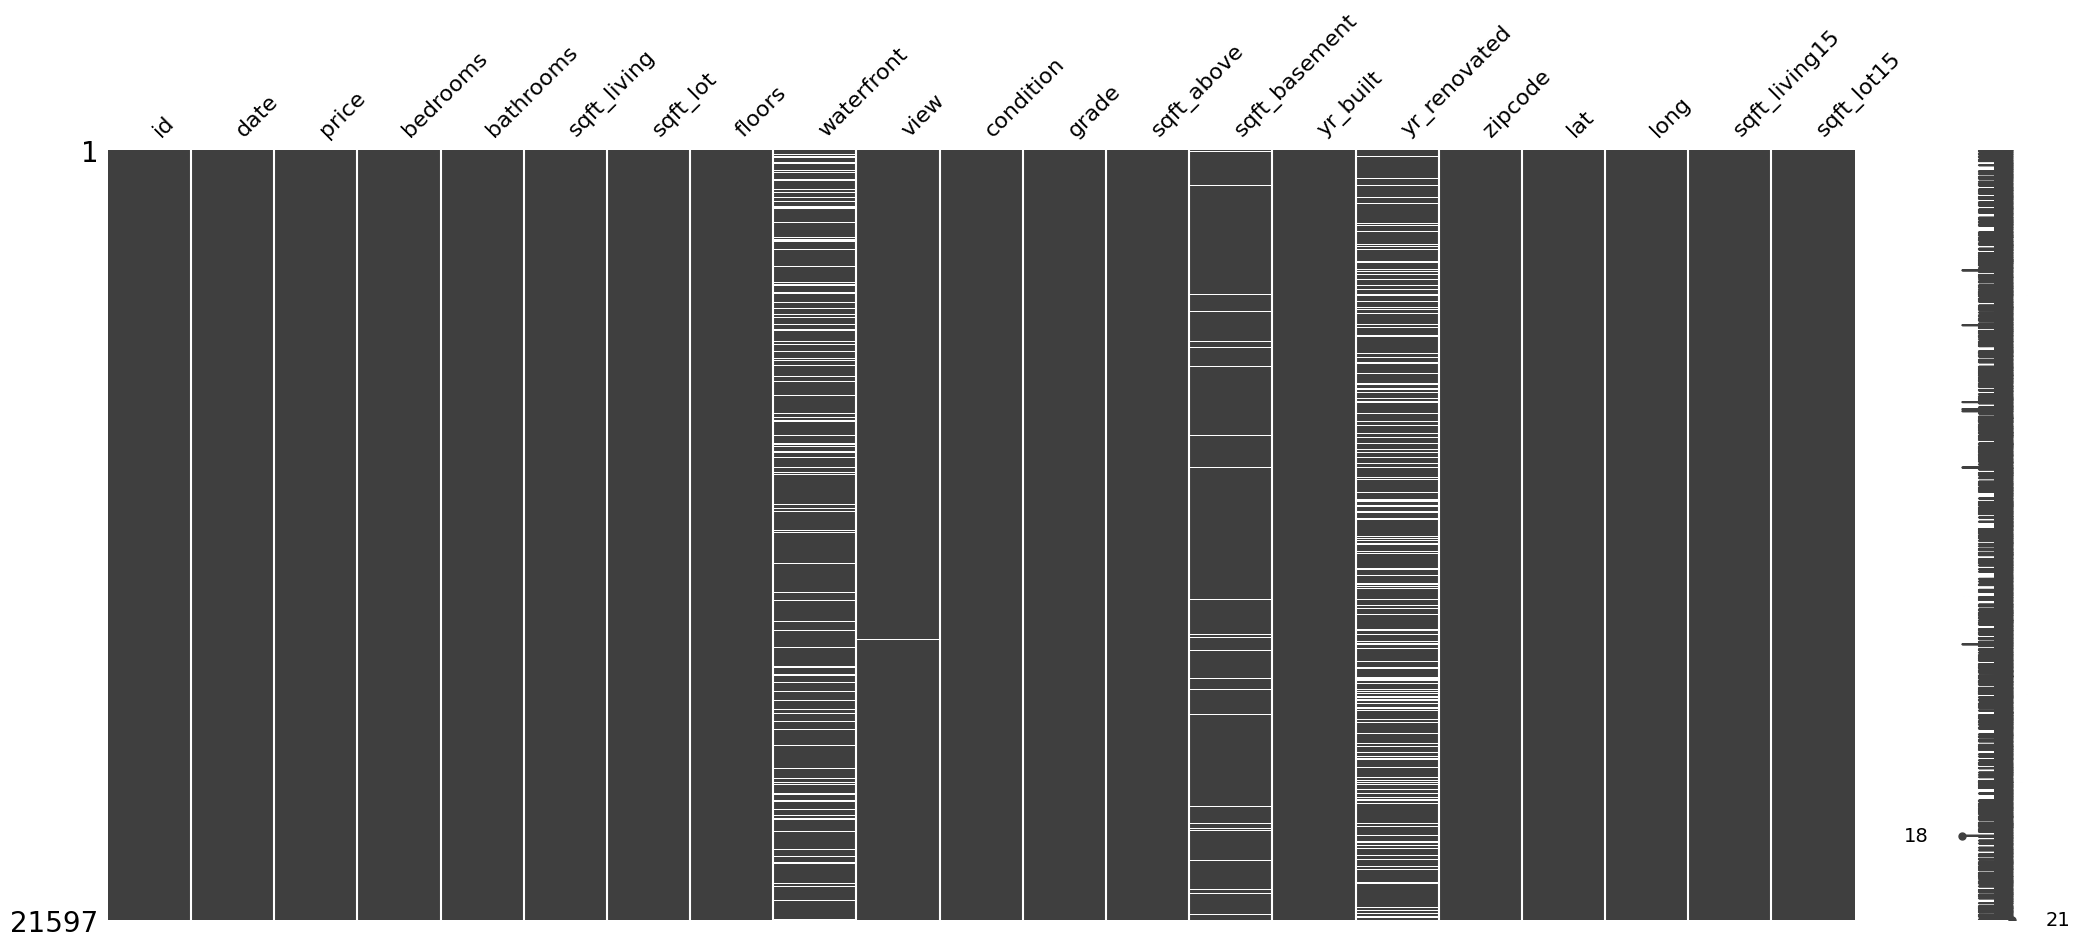

In [8]:
import missingno as msno

# Visualisiert, ob fehlende Werte zufällig verteilt oder konzentriert auftreten
msno.matrix(df)
plt.show()

**Beobachtung:** Fehlende Werte konzentrieren sich auf vier Spalten: `yr_renovated` (~17.8 %), `waterfront` (~11.1 %), `sqft_basement` (~2.1 %) und `view` (~0.3 %). Alle anderen Spalten – inklusive `price`, `bedrooms`, `bathrooms`, `sqft_living`, `zipcode`, `lat`/`long` – sind vollständig.

Das ist ein wichtiger Hinweis, aber **noch keine Handlungsanweisung**: Bei `yr_renovated` und `waterfront` könnte "fehlend" inhaltlich z.B. "nie renoviert" bzw. "kein Wasserblick" bedeuten, statt ein echter Messfehler zu sein. Wie wir damit umgehen (imputieren, als eigene Kategorie behandeln, etc.) entscheiden wir erst in der **Cleaning-Phase**, nachdem wir die Verteilungen der betroffenen Spalten genauer angeschaut haben.

### 1.5 Duplikate prüfen

Wir prüfen auf zwei Arten von "Duplikaten", die hier unterschiedliche Bedeutung haben:

1. **Komplett identische Zeilen** (alle Spaltenwerte gleich) – das wären echte Datenfehler, z.B. durch einen fehlerhaften Join.
2. **Wiederholte `id`-Werte** – da `id` das Haus identifiziert (nicht den Verkauf), bedeutet ein wiederholtes `id` lediglich, dass **dasselbe Haus mehrfach verkauft** wurde. Das ist im King-County-Datensatz normal und **kein Fehler**, den wir entfernen sollten.

In [9]:
# 1) Komplett identische Zeilen (potenzielle echte Datenfehler)
n_full_duplicates = df.duplicated().sum()
print(f"Komplett identische Zeilen: {n_full_duplicates}")

# 2) Häuser (id), die mehrfach verkauft wurden
n_extra_sale_rows = df["id"].duplicated().sum()
n_resold_houses = df["id"].value_counts().gt(1).sum()
n_unique_houses = df["id"].nunique()

print(f"Verkaufszeilen gesamt: {len(df)}")
print(f"Eindeutige Häuser (id): {n_unique_houses}")
print(f"Häuser, die mehr als einmal verkauft wurden: {n_resold_houses}")
print(f"Dadurch entstehende zusätzliche Verkaufszeilen (id erscheint mehrfach): {n_extra_sale_rows}")

Komplett identische Zeilen: 0
Verkaufszeilen gesamt: 21597
Eindeutige Häuser (id): 21420
Häuser, die mehr als einmal verkauft wurden: 176
Dadurch entstehende zusätzliche Verkaufszeilen (id erscheint mehrfach): 177


In [10]:
# Stichprobe: ein Haus, das mehrfach verkauft wurde -> unterschiedliche date/price, sonst identisch
repeated_house_id = df.loc[df["id"].duplicated(keep=False), "id"].iloc[0]
df[df["id"] == repeated_house_id].sort_values("date")[["id", "date", "price"]]

,id,date,price
93,6021501535,2014-07-25,430000.000
94,6021501535,2014-12-23,700000.000


**Beobachtung:** Es gibt **keine** komplett identischen Zeilen – der Join hat also keine Datenfehler erzeugt. Ein Teil der Häuser (ca. 176 von 21.420 eindeutigen Häusern) wurde jedoch **mehrfach verkauft**, erkennbar an gleicher `id` aber unterschiedlichem `date`/`price`. Wir behandeln diese Zeilen als **valide, eigenständige Verkaufsereignisse** und entfernen sie nicht als Duplikate.

---

## Zusammenfassung Phase 1

- Datensatz erfolgreich per SQL-Join aus `eda.king_county_house_details` und `eda.king_county_house_sales` geladen (Verkäufe zwischen Mai 2014 und Mai 2015) und lokal als CSV gecacht.
- `date` ist jetzt `datetime64` statt Text.
- Fehlende Werte konzentrieren sich auf `yr_renovated`, `waterfront`, `sqft_basement` und `view` – vermutlich fachlich erklärbar, wird in der Cleaning-Phase weiter untersucht.
- Keine fehlerhaften Duplikate; wiederholte `id`s sind legitime Mehrfachverkäufe.

**Nächste Schritte (Phase 2):** Verteilungen der einzelnen Variablen anschauen (Histogramme), Ausreißer identifizieren, anschließend auf Bonnie Browns Filter (`price <= 500000`, `bedrooms >= 3`, `bathrooms >= 1.5`) einschränken und unsere drei Hypothesen prüfen.

## Phase 2: Daten bereinigen (Cleaning)

Hashim hat die vier Spalten mit fehlenden Werten (`yr_renovated`, `waterfront`, `view`, `sqft_basement`) bereits in `Hashim/cleanfinal.ipynb` untersucht und bereinigt. Um die Arbeit nicht doppelt zu machen, übernehmen wir seine bereits verifizierte Logik hier 1:1, inklusive eines von ihm gefundenen echten Datenfehlers bei `yr_renovated`.

### 2.1 `yr_renovated`: NaN → 0 und Tippfehler-Korrektur

Ein fehlender Wert bedeutet hier vermutlich "nie renoviert" (kein Renovierungsjahr eingetragen), nicht ein Messfehler – deshalb füllen wir mit `0` statt zu löschen. Hashim hat dabei zusätzlich entdeckt, dass ein Teil der Jahreszahlen eine überzählige Endnull hat (z.B. `19910` statt `1991`). Wir korrigieren das für alle Werte über 2100.

In [11]:
df["yr_renovated"] = df["yr_renovated"].fillna(0).astype(int)

# Tippfehler-Korrektur: Werte > 2100 haben eine überzählige Endnull (z.B. 19910 statt 1991)
mask_typo = df["yr_renovated"] > 2100
df.loc[mask_typo, "yr_renovated"] = df.loc[mask_typo, "yr_renovated"] / 10

print("Betroffene Werte korrigiert:", mask_typo.sum())
print("Wertebereich yr_renovated:", df["yr_renovated"].min(), "-", df["yr_renovated"].max())

Betroffene Werte korrigiert: 744
Wertebereich yr_renovated: 0 - 2015


### 2.2 `waterfront` und `view`: NaN → 0

Beide Spalten sind stark schiefverteilt: `waterfront=1` kommt in unter 1 % aller Fälle vor, `view=0` macht ~90 % der Fälle aus. Ein fehlender Wert ist hier plausibler als "kein Wasserblick" / "keine besondere Aussicht" (0) zu interpretieren als als eigene Kategorie zu behandeln.

In [12]:
df["waterfront"] = df["waterfront"].fillna(0).astype(int)
df["view"] = df["view"].fillna(0).astype(int)

print(df["waterfront"].value_counts(normalize=True))
print()
print(df["view"].value_counts(normalize=True))

waterfront
0   0.993
1   0.007
Name: proportion, dtype: float64

view
0   0.902
2   0.044
3   0.024
1   0.015
4   0.015
Name: proportion, dtype: float64


### 2.3 `sqft_basement`: aus `sqft_living − sqft_above` rekonstruieren

Vor dem Auffüllen prüfen wir, ob bei allen Zeilen mit bekanntem `sqft_basement` die Beziehung `sqft_basement = sqft_living − sqft_above` exakt gilt. Falls ja, können wir die fehlenden Werte darüber berechnen, statt sie zu schätzen.

In [13]:
# Beziehung an allen bekannten Werten verifizieren
known = df.dropna(subset=["sqft_basement"])
relationship_holds = (known["sqft_living"] - known["sqft_above"] == known["sqft_basement"]).all()
print("Beziehung sqft_basement = sqft_living - sqft_above gilt für alle bekannten Zeilen:", relationship_holds)

# Fehlende Werte darüber berechnen
mask_basement = df["sqft_basement"].isna()
df.loc[mask_basement, "sqft_basement"] = (
    df.loc[mask_basement, "sqft_living"] - df.loc[mask_basement, "sqft_above"]
)
print("Aufgefüllte Werte:", mask_basement.sum())

Beziehung sqft_basement = sqft_living - sqft_above gilt für alle bekannten Zeilen: True
Aufgefüllte Werte: 452


In [14]:
# Finale Kontrolle: keine fehlenden Werte mehr im gesamten Datensatz
df.isnull().sum().sum()

np.int64(0)

**Zusammenfassung Phase 2:** Alle vier betroffenen Spalten sind jetzt vollständig, ohne dass wir Zeilen gelöscht oder Werte grob geraten haben – jede Entscheidung basiert auf einer inhaltlichen Begründung (dominanter Wert, Beziehung zwischen Spalten) oder auf einer verifizierten Korrektur.

---

## Phase 3: Hypothese 2 – "Renovation / Condition / Grade correspond to higher price points"

Diese Hypothese wurde mir (Sonson) vom Team zur Untersuchung zugeteilt.

> ⚠️ **Korrigiert (2026-07-31):** Auch diese Einleitung ging noch von der falschen Buyer-Annahme aus ("Bonnie kauft günstig in einem Budget-Segment ein"). Laut `01_assignment.md` ist Bonnie tatsächlich **Verkäuferin** – siehe Abschnitt 3.4 für die volle Herleitung. Reframed als **Renovation ROI**: Lohnt es sich für Bonnie, ihr Haus (`condition == 3`) vor dem Verkauf zu renovieren, um einen höheren Profit zu erzielen?

Wir prüfen das in zwei Schritten:

1. Zuerst auf dem **gesamten Datensatz**: Wie hängen `grade`, `condition` und Renovierungsstatus generell mit dem Preis zusammen?
2. Dann **gezielt innerhalb von Bonnies Mittelschicht-Nachbarschaft** (Definition siehe Abschnitt 3.4), auf Basis von `price / sqft_living` – denn als Verkäuferin interessiert sie der erzielbare Preis für ihr eigenes Haus, kein Budget-Limit.

### 3.1 Preis nach `grade` (gesamter Datensatz)

`grade` ist King Countys eigenes Bewertungssystem für Bauqualität/-ausstattung (3 = niedrig, 13 = sehr hoch). Wir schauen uns die Preisverteilung je Grade-Stufe an.

       count      median        mean
grade                               
3          1  262000.000  262000.000
4         27  200000.000  212001.852
5        242  228700.000  248523.971
6       2038  275276.500  301916.571
7       8974  375000.000  402594.573
8       6065  510000.000  542986.800
9       2615  720000.000  773738.222
10      1134  914327.000 1072347.467
11       399 1280000.000 1497792.378
12        89 1820000.000 2202528.090
13        13 2980000.000 3710769.231

Korrelation grade <-> price: 0.67


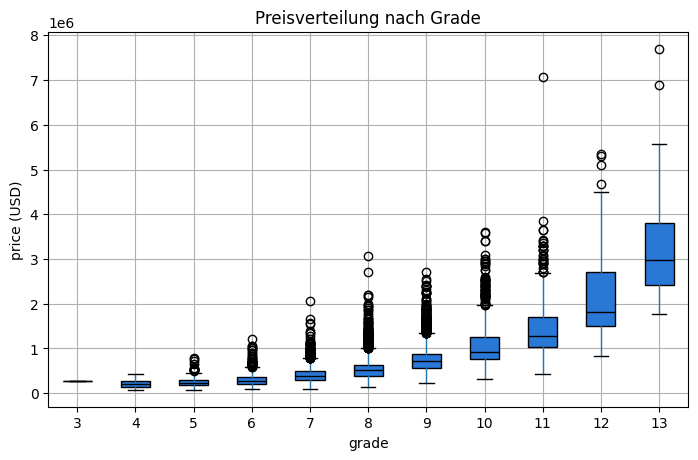

In [15]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nKorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Sehr klarer, nahezu monotoner Zusammenhang – der Median-Preis steigt von 262.000 $ (Grade 3) auf 2.980.000 $ (Grade 13). Korrelation `grade` ↔ `price`: **0.67** – der stärkste Einzelfaktor, den wir bisher gesehen haben. Für Hypothese 2 heißt das: **Grade bestätigt die Hypothese eindeutig.**

**Observation:** A very clear, almost monotonic relationship — the median price rises from $262,000 (grade 3) to $2,980,000 (grade 13). Correlation `grade` ↔ `price`: **0.67** — the strongest single factor we've seen so far. For Hypothesis 2, this means: **grade clearly confirms the hypothesis.**

### 3.2 Preis nach `condition` (gesamter Datensatz)

`condition` bewertet den allgemeinen Erhaltungszustand (1 = schlecht, 5 = sehr gut).

           count     median       mean
condition                             
1             29 270000.000 341067.241
2            170 279000.000 328178.759
3          14020 450250.000 542173.057
4           5677 440000.000 521374.450
5           1701 526000.000 612577.743

Korrelation condition <-> price: 0.04


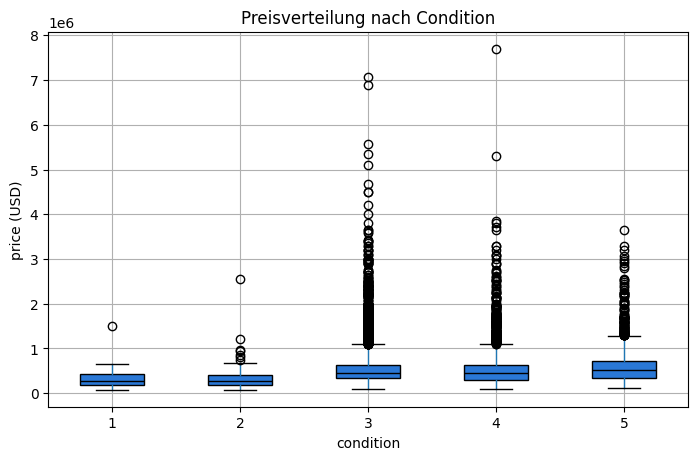

In [16]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nKorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als bei `grade` ist der Zusammenhang hier **schwach** – Korrelation `condition` ↔ `price`: nur **0.04**. `condition == 3` (Median 450.250 $) unterscheidet sich kaum von `condition == 4` (440.000 $) und liegt sogar leicht *unter* `condition == 5` (526.000 $), aber über `condition == 1`/`2` (kleine Stichproben, 29 bzw. 170 Häuser). Für Hypothese 2 heißt das: **`condition` allein erklärt den Preis über den gesamten Markt kaum** – der Effekt aus der Hypothese scheint fast ausschließlich über `grade` zu laufen, nicht über `condition`.

**Observation:** Unlike `grade`, the relationship here is **weak** — correlation `condition` ↔ `price`: only **0.04**. `condition == 3` (median $450,250) is barely different from `condition == 4` ($440,000), and even slightly *below* `condition == 5` ($526,000), though above `condition == 1`/`2` (small samples, 29 and 170 homes respectively). For Hypothesis 2, this means: **`condition` alone barely explains price across the whole market** — the effect implied by the hypothesis seems to run almost entirely through `grade`, not through `condition`.

### 3.3 Renovierte vs. nicht renovierte Häuser (gesamter Datensatz)

Wir leiten aus `yr_renovated` ein einfaches Flag `is_renovated` ab (`yr_renovated > 0`) und vergleichen sowohl den absoluten Preis als auch den Preis pro Quadratfuß (`price / sqft_living`), um Größeneffekte herauszurechnen.

              count     median       mean
is_renovated                             
False         20853 449000.000 532140.320
True            744 607502.000 768901.892

              median    mean
is_renovated                
False        243.191 262.103
True         301.563 321.338

Korrelation is_renovated <-> price: 0.12


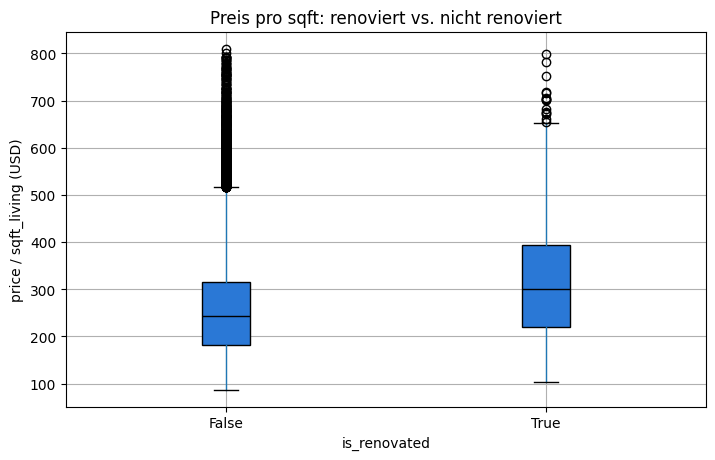

In [17]:
df["is_renovated"] = df["yr_renovated"] > 0
df["price_per_sqft"] = df["price"] / df["sqft_living"]

print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nKorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preis pro sqft: renoviert vs. nicht renoviert")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Renovierte Häuser (744 von 21.597, ca. 3.4 %) kosten median **607.502 $** vs. **449.000 $** bei nicht renovierten – auch pro Quadratfuß liegt der Median bei **302 $** vs. **243 $**. Korrelation `is_renovated` ↔ `price`: **0.12** – moderat, schwächer als `grade`, aber klar stärker als `condition`. Renovierung zeigt also einen sichtbaren Preisaufschlag.

**Observation:** Renovated homes (744 of 21,597, ~3.4%) sell for a median of **$607,502** vs. **$449,000** for non-renovated ones — the median price per square foot is also higher: **$302** vs. **$243**. Correlation `is_renovated` ↔ `price`: **0.12** — moderate, weaker than `grade` but clearly stronger than `condition`. Renovation does show a visible price premium.

### 3.4 Bonnies reale Rolle: Verkäuferin in einer Mittelschicht-Nachbarschaft

**Korrektur:** Die Analyse ab hier ging ursprünglich fälschlich davon aus, dass Bonnie eine Käuferin mit Budget ≤ 500.000 $ ist. Laut offizieller Aufgabenstellung (`01_assignment.md`) ist Bonnie Brown tatsächlich **Verkäuferin**: Sie besitzt bereits ein Haus in einer **Mittelschicht-Nachbarschaft** ("middle class NH"), will bald umziehen und dabei einen **möglichst hohen Profit** erzielen. Die Analyse ab 3.4 wurde entsprechend neu aufgesetzt – statt "günstig kaufen im Budget-Segment" geht es jetzt um "Profit beim Verkauf eines Mittelschicht-Hauses".

**Annahme (explizit, da der Datensatz keine Nachbarschafts-Klasse enthält):** Wir definieren "Mittelschicht-Nachbarschaft" über den **Zipcode-Median-Preis** – alle Zipcodes werden anhand ihres Median-Hauspreises in drei gleich große Gruppen (Terzile) eingeteilt: unteres, mittleres und oberes Preis-Drittel. Jedes Haus erbt die Klasse seines Zipcodes. Das mittlere Terzil = "middle class".

In [18]:
zip_median_price = df.groupby("zipcode")["price"].median()
neighborhood_class = pd.qcut(zip_median_price, 3, labels=["lower", "middle", "upper"])
df["neighborhood_class"] = df["zipcode"].map(neighborhood_class.to_dict())

print(df["neighborhood_class"].value_counts())
print("\nZipcode-Median-Preisspannen je Klasse:")
print(zip_median_price.groupby(neighborhood_class).agg(["min", "max", "count"]))

bonnie = df[df["neighborhood_class"] == "middle"].copy()
print(f"\nH\u00e4user in Mittelschicht-Nachbarschaften: {len(bonnie)} ({len(bonnie) / len(df):.1%} des Gesamtmarkts)")

neighborhood_class
lower     7795
upper     7011
middle    6791
Name: count, dtype: int64

Zipcode-Median-Preisspannen je Klasse:
              min         max  count
price                               
lower  235000.000  375000.000     25
middle 380000.000  554000.000     22
upper  555000.000 1895000.000     23

Häuser in Mittelschicht-Nachbarschaften: 6791 (31.4% des Gesamtmarkts)


**Beobachtung:** 70 Zipcodes verteilen sich auf drei etwa gleich große Gruppen. Die "middle"-Klasse (22 Zipcodes, 6.791 Häuser, ca. 31 % des Marktes) umfasst Zipcodes mit einem Median-Hauspreis zwischen 380.000 $ und 554.000 $ – eine klar mittlere Preisklasse zwischen den unteren (235.000–375.000 $, 25 Zipcodes) und oberen (555.000–1.895.000 $, 23 Zipcodes) Zipcode-Terzilen. Das ist unsere Arbeitsdefinition von "middle class neighborhood" für Bonnies Haus – `bonnie` bezeichnet ab jetzt alle Häuser in dieser Nachbarschaftsklasse, nicht mehr ein Budget-Segment.

#### `condition == 3` vs. andere Zustände – innerhalb der Mittelschicht-Nachbarschaften

In [19]:
bonnie.groupby(bonnie["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
condition,,,
False,2352,276.219,293.831
True,4439,248.516,271.266


**Beobachtung:** Innerhalb der Mittelschicht-Nachbarschaften liegt der Median-Preis pro Quadratfuß bei `condition == 3` (4.439 Häuser) bei **249 $**, verglichen mit **276 $** bei besser bewerteten Zuständen (2.352 Häuser) – ein Abschlag von rund **10 %**. Anders als in der alten, budget-limitierten Analyse zeigt sich hier also durchaus ein Discount für durchschnittlichen Zustand. Für Bonnie heißt das: Wenn ihr Haus in `condition == 3` ist, verkauft es sich tendenziell günstiger pro Quadratfuß als besser erhaltene Häuser in derselben Nachbarschaftsklasse – genau die Ausgangslage, vor der sich die Frage nach einer Renovierung stellt.

#### ROI-Analyse: Lohnt sich eine Renovierung vor dem Verkauf?

Bonnies eigentliche Frage: Ihr Haus hat `condition == 3`. Würde eine Renovierung vor dem Verkauf den Gewinn ausreichend steigern, um sich zu lohnen? Wir vergleichen dazu bereits renovierte mit nicht renovierten Häusern, die *innerhalb* von `condition == 3` in Mittelschicht-Nachbarschaften verkauft wurden.

             price                       price_per_sqft                
             count     median       mean          count  median    mean
is_renovated                                                           
False         4238 465000.000 518476.957           4238 247.100 269.171
True           201 635500.000 690363.786            201 300.755 315.438

Median-Preis renoviert: 635,500 $ vs. nicht renoviert: 465,000 $ -> +36.7 %
Median-Preis/sqft renoviert: 301 $ vs. nicht renoviert: 247 $ -> +21.7 %
Korrelation is_renovated <-> price: 0.14


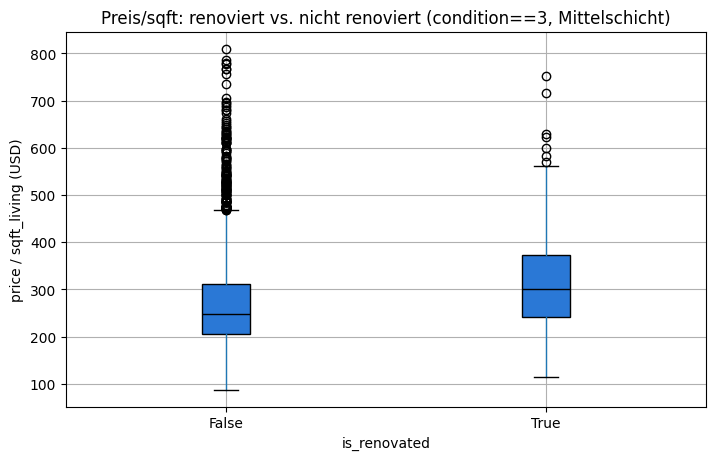

In [20]:
bonnie_cond3 = bonnie[bonnie["condition"] == 3].copy()

print(bonnie_cond3.groupby("is_renovated")[["price", "price_per_sqft"]].agg(["count", "median", "mean"]))

median_price_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price"].median()
median_price_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price"].median()
price_uplift_pct = (median_price_reno / median_price_noreno - 1) * 100

median_psf_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price_per_sqft"].median()
median_psf_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price_per_sqft"].median()
psf_uplift_pct = (median_psf_reno / median_psf_noreno - 1) * 100

print(f"\nMedian-Preis renoviert: {median_price_reno:,.0f} $ vs. nicht renoviert: {median_price_noreno:,.0f} $ -> +{price_uplift_pct:.1f} %")
print(f"Median-Preis/sqft renoviert: {median_psf_reno:,.0f} $ vs. nicht renoviert: {median_psf_noreno:,.0f} $ -> +{psf_uplift_pct:.1f} %")
print("Korrelation is_renovated <-> price:", bonnie_cond3["is_renovated"].astype(int).corr(bonnie_cond3["price"]).round(2))

fig, ax = plt.subplots()
bonnie_cond3.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
                     boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                     medianprops={"color": "black"})
ax.set_title("Preis/sqft: renoviert vs. nicht renoviert (condition==3, Mittelschicht)")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Innerhalb von `condition == 3` in Mittelschicht-Nachbarschaften kosten bereits renovierte Häuser (201 von 4.439, ca. 4.5 %) median **635.500 $** vs. **465.000 $** bei nicht renovierten – ein Aufschlag von **+36,7 %** beim absoluten Preis bzw. **+21,7 %** beim Preis pro Quadratfuß (301 $ vs. 247 $). Korrelation `is_renovated` ↔ `price`: **0.14** – etwas stärker als am Gesamtmarkt (0.12).

**Einordnung / ROI-Vorbehalt:** Der Datensatz enthält keine Renovierungskosten, daher lässt sich kein exakter ROI (Gewinn abzüglich Kosten) berechnen – nur die Preisdifferenz. Typische Renovierungskosten für ein Einfamilienhaus dieser Größenordnung (Küche, Bad, kosmetische Auffrischung) liegen laut gängigen Branchenschätzungen grob bei 20.000–80.000 $ – verglichen mit einem Median-Aufschlag von rund **170.500 $** wirkt eine Renovierung finanziell attraktiv. **Aber:** Die renovierte Gruppe ist klein (201 Häuser) und nicht zufällig ausgewählt – Eigentümer, die renovieren, pflegen ihr Haus möglicherweise auch sonst besser (nicht erfasste Faktoren), sodass ein Teil des Aufschlags nicht direkt auf die Renovierung selbst zurückzuführen sein muss. **Für Bonnie heißt das:** Die Daten sprechen tendenziell für eine Renovierung vor dem Verkauf, aber die tatsächliche Kostenseite muss sie selbst kalkulieren – die Preisdifferenz allein ist ein Signal, ersetzt aber keine echte Kostenschätzung.

#### Präsentations-Chart (Slide 2): Preis/sqft renoviert vs. nicht renoviert

Vereinfachte Balken-Version der Boxplot-Analyse oben – zwei Werte direkt beschriftet, für eine nicht-technische Stakeholder-Folie.

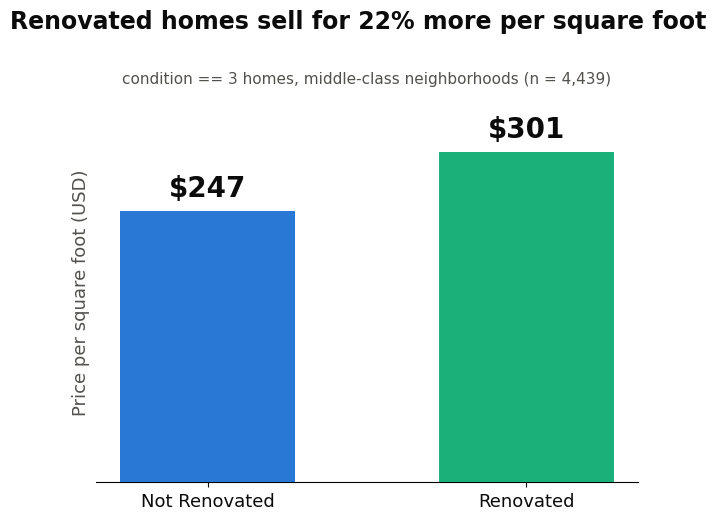

In [21]:
renovation_medians = bonnie_cond3.groupby("is_renovated")["price_per_sqft"].median()
labels = ["Not Renovated", "Renovated"]
values = [round(renovation_medians[False]), round(renovation_medians[True])]
colors = ["#2a78d6", "#1baf7a"]

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.subplots_adjust(top=0.80)

bars = ax.bar(labels, values, color=colors, width=0.55, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 8, f"${val}",
            ha="center", va="bottom", fontsize=20, fontweight="bold", color="#0b0b0b")

ax.set_ylim(0, max(values) + 45)
ax.set_ylabel("Price per square foot (USD)", fontsize=13, color="#52514e")
fig.suptitle("Renovated homes sell for 22% more per square foot",
             fontsize=17, fontweight="bold", y=0.97, color="#0b0b0b")
ax.set_title("condition == 3 homes, middle-class neighborhoods (n = 4,439)",
             fontsize=11, color="#52514e", pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", left=False, labelleft=False)
ax.tick_params(axis="x", labelsize=13, colors="#0b0b0b")
ax.set_axisbelow(True)
plt.show()

#### `grade` innerhalb der Mittelschicht-Nachbarschaften (Kontext)

Zur Einordnung: Gilt der starke Zusammenhang zwischen `grade` und Preis (3.1, Korrelation 0.67) auch innerhalb der Mittelschicht-Nachbarschaften, oder war er – wie in der alten, budget-limitierten Analyse – nur ein Artefakt des Budget-Deckels?

       count  median    mean
grade                       
4          9 463.158 392.937
5        104 272.636 322.940
6        631 289.773 311.444
7       3102 263.786 280.844
8       1961 249.714 266.147
9        689 231.502 256.063
10       194 268.254 303.472
11        82 275.172 312.792
12        15 351.931 390.756
13         4 348.671 423.526



Korrelation grade <-> price (Mittelschicht-Segment): 0.65


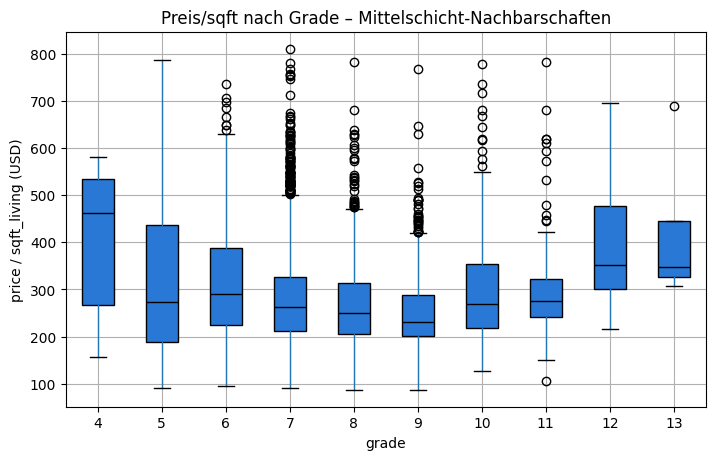

In [22]:
bonnie_grade = bonnie.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(bonnie_grade)
print("\nKorrelation grade <-> price (Mittelschicht-Segment):", bonnie["grade"].corr(bonnie["price"]).round(2))

fig, ax = plt.subplots()
bonnie.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
               boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
               medianprops={"color": "black"})
ax.set_title("Preis/sqft nach Grade – Mittelschicht-Nachbarschaften")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als in der alten, budget-limitierten Analyse bricht der Zusammenhang zwischen `grade` und Preis hier **nicht** zusammen – die Korrelation mit dem absoluten Preis bleibt mit **0.65** fast identisch zum Gesamtmarkt (0.67). Der Preis *pro Quadratfuß* verläuft dagegen nicht streng monoton über die Grades (z. B. niedriger bei Grade 8–9 als bei Grade 6–7) – das ist aber ein bekannter, allgemeiner Immobilieneffekt (kleinere Häuser haben tendenziell einen höheren Preis pro Quadratfuß) und kein Bonnie-spezifisches Problem. Für Bonnie ist `grade` als Kontextvariable relevant, aber nicht der Kern ihrer Frage – sie kann ihren eigenen Grade i.d.R. nicht ändern, nur den Zustand (Renovierung).

## Zusammenfassung Hypothese 2 (Renovation ROI)

| Faktor | Gesamtmarkt | Mittelschicht-Nachbarschaften (Bonnies Segment) |
|---|---|---|
| `grade` | Starker Treiber (Korrelation 0.67) | Weiterhin starker Treiber (Korrelation 0.65) – kein Budget-Deckeneffekt mehr |
| `condition` | Schwach (Korrelation 0.04) | `condition == 3`: **10 % Discount** ggü. besseren Zuständen (249 $ vs. 276 $/sqft) |
| Renovierung (condition==3) | Moderat (Korrelation 0.12), +35 % Median-Preis | **+36,7 %** Median-Preis, **+21,7 %** Preis/sqft bei renovierten Häusern (Korrelation 0.14) |

**Fazit für Bonnie Brown (Seller):** Bonnies Haus in `condition == 3` verkauft sich in ihrer Mittelschicht-Nachbarschaft tendenziell zu einem niedrigeren Preis pro Quadratfuß als besser bewertete Häuser. Eine Renovierung vor dem Verkauf zeigt einen deutlichen Preisaufschlag (+36,7 % Median-Preis, +21,7 % pro sqft) – deutlich stärker als in der ursprünglichen (fehlerhaften) Buyer-Analyse (+7 %). **Empfehlung:** Eine Renovierung vor dem Verkauf erscheint auf Basis der Preisdaten lohnenswert, sofern die tatsächlichen Renovierungskosten deutlich unter dem beobachteten Preisaufschlag (Median ca. 170.500 $) liegen – das muss Bonnie mit einer echten Kostenschätzung abgleichen, da der Datensatz keine Renovierungskosten enthält und die renovierte Stichprobe klein ist (201 Häuser).

**Nächste Schritte:** Hypothese 1 (Location Value) und Hypothese 3 (Timing) stehen noch aus und müssen ebenfalls an Bonnies Rolle als Verkäuferin angepasst werden – vermutlich durch Hashim und Evelyn.

## Summary: Hypothesis 2 – Renovation ROI (English)

| Factor | Overall market | Middle-class neighborhoods (Bonnie's segment) |
|---|---|---|
| `grade` | Strong driver (correlation 0.67) | Still a strong driver (correlation 0.65) — no budget-ceiling artifact here |
| `condition` | Weak (correlation 0.04) | `condition == 3`: **10% discount** vs. better-rated homes ($249 vs. $276/sqft) |
| Renovation (condition==3) | Moderate (correlation 0.12), +35% median price | **+36.7%** median price, **+21.7%** price/sqft for renovated homes (correlation 0.14) |

**Conclusion for Bonnie Brown (Seller):** Bonnie's home in `condition == 3` tends to sell for a lower price per square foot than better-rated homes in her middle-class neighborhood. Renovating before selling shows a clear price premium (+36.7% median price, +21.7% per sqft) — notably larger than the original (flawed) buyer-framed analysis found (+7%). **Recommendation:** based on the price data alone, renovating before selling looks worthwhile, provided actual renovation costs stay well below the observed premium (median ~$170,500) — Bonnie needs to check this against a real cost estimate, since the dataset contains no renovation-cost data and the renovated sample is small (201 homes).

**Next steps:** Hypothesis 1 (location value) and Hypothesis 3 (timing) are still open and also need to be reframed around Bonnie's role as a seller — likely by Hashim and Evelyn.